In [10]:
pip install grad-cam --quiet


Note: you may need to restart the kernel to use updated packages.


In [11]:
import timm
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import random
from PIL import Image
from torchvision import transforms
import os

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
import timm
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model("vit_tiny_patch16_224", pretrained=False, img_size=128, num_classes=1)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model = model.to(device)
model.eval()


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()


In [14]:
img_dir = "data/train_data"  # update if you're using a different folder

# Get list of all image filenames
image_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Pick a random one
random_img = random.choice(image_files)
img_path = os.path.join(img_dir, random_img)

# Load and preprocess the image
image = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((128, 128)),  # match training resolution
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

input_tensor = transform(image).unsqueeze(0).to(device)

print(f"Random image selected: {random_img}")

Random image selected: 4f94bdcf055d4662baa030a3836b4159.jpg


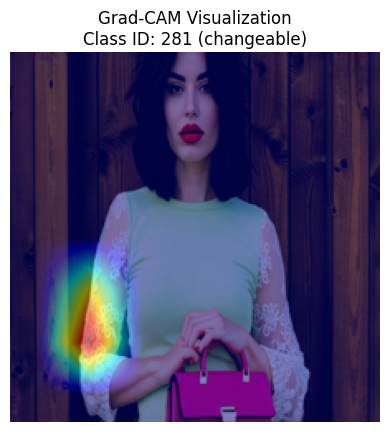

Visualized image: 0dc74a8a005c4c3b985a9b2b06e525ad.jpg


In [ ]:


# Step 2: Imports
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Step 3: Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Step 4: Load pretrained ResNet model
model = models.resnet50(pretrained=True)
model.eval().to(device)

# Step 5: Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # For ResNet50
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Step 6: Select a random image from your folder
img_folder = "data/train_data"  # replace with your actual folder
image_files = [f for f in os.listdir(img_folder) if f.endswith(('.jpg', '.png'))]
random_img = random.choice(image_files)
img_path = os.path.join(img_folder, random_img)

# Step 7: Load and preprocess image
image = Image.open(img_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)
original_img = np.array(image.resize((224, 224))).astype(np.float32) / 255.0

# Step 8: Define Grad-CAM target
target_layers = [model.layer4[-1]]  # last conv layer in ResNet50
targets = [ClassifierOutputTarget(0)]  # change to class index you want, 281 = tabby cat (example)

# Step 9: Run Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
visualization = show_cam_on_image(original_img, grayscale_cam, use_rgb=True)

# Step 10: Display results
plt.imshow(visualization)
plt.title(f"Grad-CAM Visualization\nClass ID: 281 (changeable)")
plt.axis("off")
plt.show()

# Optional: print image used
print(f"Visualized image: {random_img}")


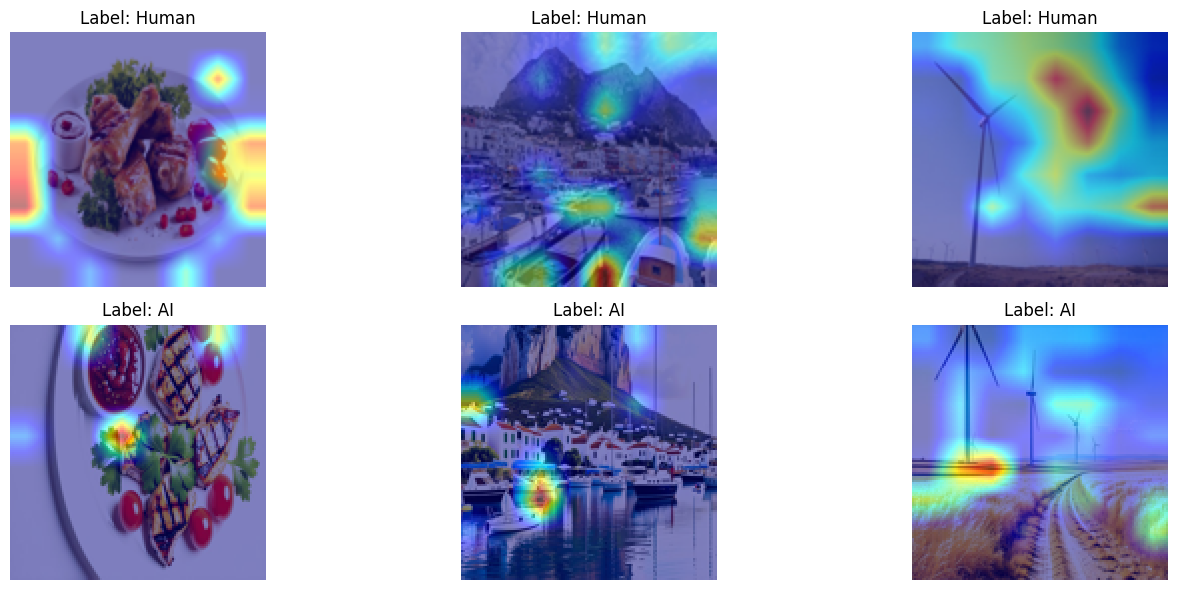

In [36]:
import torch
import pandas as pd
import random
import os
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from timm import create_model

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ---- Setup ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=128)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# ---- Image Preprocessing ----
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- Reshape for ViT ----
def reshape_transform(tensor, height=8, width=8):
    tensor = tensor[:, 1:, :]
    B, N, C = tensor.size()
    return tensor.reshape(B, height, width, C).permute(0, 3, 1, 2)

# ---- GradCAM Setup ----
target_layers = [model.blocks[-1].norm1]
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

# ---- Load dataset and sample images ----
df = pd.read_csv("data/train.csv")
data_folder = "data/train_data"

num_per_class = 3
samples_human = df[df["label"] == 0].sample(num_per_class, random_state=42)
samples_ai = df[df["label"] == 1].sample(num_per_class, random_state=42)
samples = pd.concat([samples_human, samples_ai])

# ---- Visualization ----
plt.figure(figsize=(15, 6))
for idx, row in enumerate(samples.itertuples(), 1):
    img_path = os.path.join("data", row.file_name)
    image = Image.open(img_path).convert("RGB")

    original_img = np.array(image.resize((128, 128))).astype(np.float32) / 255.0
    input_tensor = transform(image).unsqueeze(0).to(device)
    target = [ClassifierOutputTarget(0)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=target)[0]
    visualization = show_cam_on_image(original_img, grayscale_cam, use_rgb=True)

    plt.subplot(2, 3, idx)
    plt.imshow(visualization)
    plt.title(f"Label: {'Human' if row.label==0 else 'AI'}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [37]:
def run_gradcam_on_dataset(model, df, image_dir, label_map, output_dir="cam_outputs"):
    for idx, row in df.iterrows():
        image_path = os.path.join(image_dir, row.file_name)
        label = row.label
        pred_prob, cam_img = generate_cam(model, image_path, label)
        save_cam_image(cam_img, pred_prob, label, output_dir, idx)


In [39]:
import pandas as pd

submission = pd.read_csv("submission.csv")  # make sure the name matches the uploaded file
print(" Columns:", submission.columns.tolist())
print(" Shape:", submission.shape)
submission.head()


 Columns: ['id', 'label']
 Shape: (5540, 2)


,id,label
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg,0
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg,0
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg,0
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg,0
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg,0


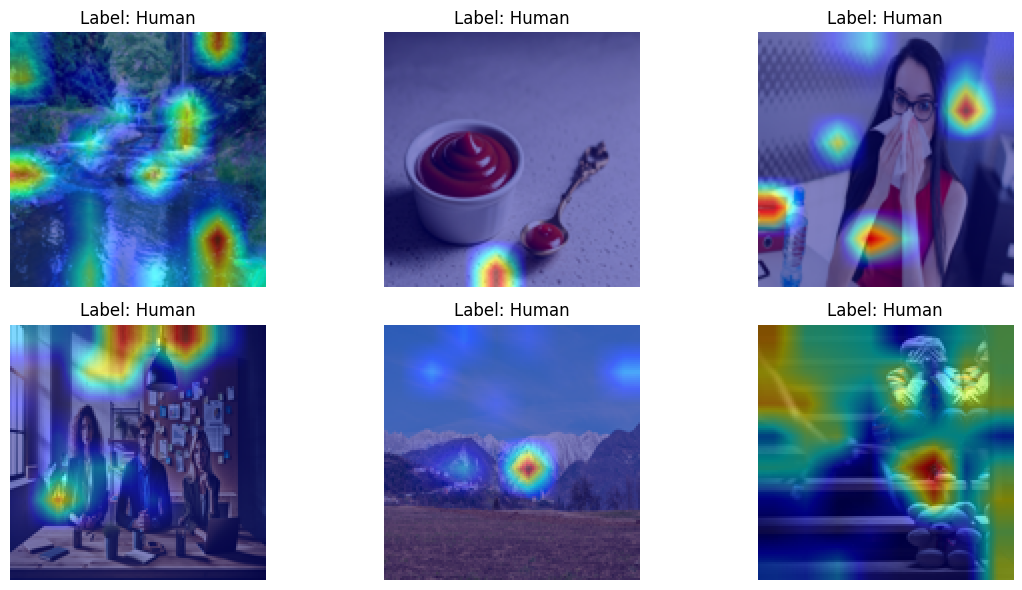

In [42]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch
from timm import create_model
import numpy as np

# Load submission file
submission = pd.read_csv("submission.csv")

# Fix path
submission["id"] = submission["id"].apply(lambda x: os.path.join("data", x))

# Sample 6 random images
samples = submission.sample(6, random_state=42)

# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=128)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# GradCAM target layer
target_layers = [model.blocks[-1].norm1]

# Image transform
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Reshape function for ViT
def reshape_transform(tensor, height=8, width=8):
    tensor = tensor[:, 1:, :]  # Remove CLS token
    B, N, C = tensor.shape
    return tensor.reshape(B, height, width, C).permute(0, 3, 1, 2)

# Initialize CAM
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

# Plot
plt.figure(figsize=(12, 6))
for idx, row in enumerate(samples.itertuples(), 1):
    try:
        image = Image.open(row.id).convert("RGB")
        original_img = np.array(image.resize((128, 128))).astype(np.float32) / 255.0
        input_tensor = transform(image).unsqueeze(0).to(device)

        target = [ClassifierOutputTarget(row.label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=target)[0]
        visualization = show_cam_on_image(original_img, grayscale_cam, use_rgb=True)

        plt.subplot(2, 3, idx)
        plt.imshow(visualization)
        plt.title(f"Label: {'Human' if row.label == 0 else 'AI'}")
        plt.axis("off")
    except Exception as e:
        print(f"Failed for {row.id}: {e}")

plt.tight_layout()
plt.show()


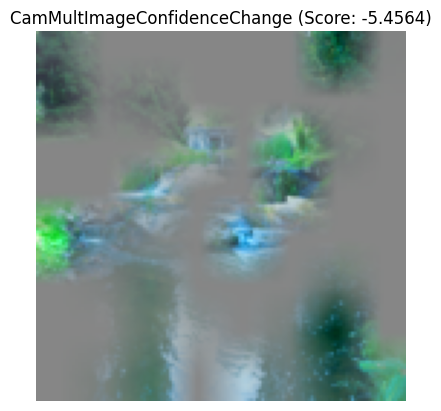

In [50]:
import os
import torch
import pandas as pd
import numpy as np
from PIL import Image
from torchvision import transforms
from timm import create_model
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, deprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.metrics.cam_mult_image import CamMultImageConfidenceChange

# ---- SETUP ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=128)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# ---- CAM SETUP ----
def reshape_transform(tensor, height=8, width=8):
    tensor = tensor[:, 1:, :]  # remove CLS token
    B, N, C = tensor.size()
    return tensor.reshape(B, height, width, C).permute(0, 3, 1, 2)

target_layers = [model.blocks[-1].norm1]
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

# ---- TRANSFORM ----
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- LOAD TEST DATA ----
test_df = pd.read_csv("submission.csv")  # Assuming it contains ['id', 'label']
image_dir = "data/test_data_v2"

# ---- SAMPLE 10 IMAGES ----
sample_df = test_df.sample(10, random_state=42).reset_index(drop=True)

input_tensors = []
rgb_images = []
targets = []

for _, row in sample_df.iterrows():
    img_path = os.path.join(image_dir, os.path.basename(row['id']))
    
    try:
        image = Image.open(img_path).convert("RGB")
    except FileNotFoundError:
        print(f"⚠️ Image not found: {img_path}")
        continue

    rgb_np = np.array(image.resize((128, 128))).astype(np.float32) / 255.0
    rgb_images.append(rgb_np)

    tensor = transform(image).unsqueeze(0).to(device)
    input_tensors.append(tensor)

    label = int(row['label'])  # Assuming 0 = Human, 1 = AI
    targets.append(ClassifierOutputTarget(label))

# ---- STACK BATCH ----
if len(input_tensors) == 0:
    raise ValueError("No valid images found!")

input_tensor = torch.cat(input_tensors, dim=0)

# ---- APPLY METRIC ----
metric = CamMultImageConfidenceChange()

with cam:
    grayscale_cams = cam(input_tensor=input_tensor, targets=targets)
    scores, visualizations = metric(
        input_tensor=input_tensor,
        cams=grayscale_cams,
        targets=targets,
        model=model,
        return_visualization=True
    )

# ---- SHOW 1 RESULT ----
idx = 0  # You can loop or pick others
vis_img = visualizations[idx]
if isinstance(vis_img, torch.Tensor):
    vis_img = vis_img.cpu().numpy()

vis_img = deprocess_image(vis_img)

plt.imshow(vis_img.transpose(1, 2, 0))  # fix shape
plt.title(f"CamMultImageConfidenceChange (Score: {scores[idx]:.4f})")
plt.axis("off")
plt.show()



In [54]:
import torch
from torchvision import transforms
from PIL import Image
import numpy as np
from timm import create_model
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.metrics.road import ROADMostRelevantFirst, ROADLeastRelevantFirst

# --------------------
# Model setup
# --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=128)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# --------------------
# Image transform
# --------------------
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --------------------
# Reshape function for ViT
# --------------------
def reshape_transform(tensor, height=8, width=8):  # 128x128 / patch 16 = 8x8
    tensor = tensor[:, 1:, :]  # remove CLS token
    B, N, C = tensor.size()
    return tensor.reshape(B, height, width, C).permute(0, 3, 1, 2)

# --------------------
# Load sample image
# --------------------
img_path = "data/test_data_v2/0016e1d72d404fe68074cc87cb30aa37.jpg"  # Replace with your actual path
image = Image.open(img_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)
targets = [ClassifierOutputTarget(0)]  # or 1 for AI class

# --------------------
# Set target layer for ViT attention output
# --------------------
target_layers = [model.blocks[-1].attn.proj]

# --------------------
# Initialize GradCAM with reshape
# --------------------
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)
grayscale_cams = cam(input_tensor=input_tensor, targets=targets)

# --------------------
# ROAD Metrics
# --------------------
road_most = ROADMostRelevantFirst(percentile=75)
road_least = ROADLeastRelevantFirst(percentile=75)

score_most = road_most(input_tensor, grayscale_cams, targets, model)
score_least = road_least(input_tensor, grayscale_cams, targets, model)

# --------------------
# Print scores
# --------------------
print(f"ROAD Most Relevant First Score:  {score_most[0]:.4f}")
print(f" ROAD Least Relevant First Score: {score_least[0]:.4f}")


ROAD Most Relevant First Score:  5.3420
 ROAD Least Relevant First Score: 5.3701


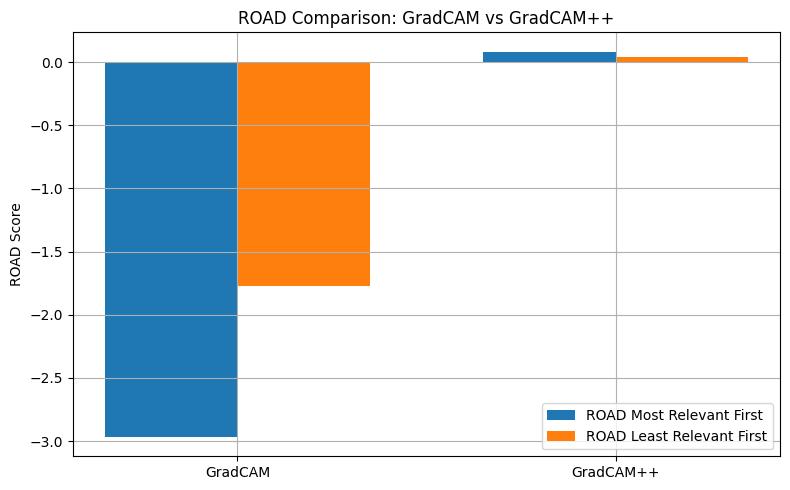

In [57]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
from torchvision import transforms
from timm import create_model

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.metrics.road import ROADMostRelevantFirst, ROADLeastRelevantFirst
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=128)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# --- Reshape transform for ViT ---
def reshape_transform(tensor, height=8, width=8):
    tensor = tensor[:, 1:, :]
    B, N, C = tensor.size()
    return tensor.reshape(B, height, width, C).permute(0, 3, 1, 2)

# --- Image preprocessing ---
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Load dataset with labels ---
df = pd.read_csv("submission.csv")  # must contain 'id' and 'label'
df = df[df['label'].isin([0, 1])]  # only valid classes

# Sample 5 Human and 5 AI examples
batch_df = pd.concat([
    df[df["label"] == 0].sample(5, random_state=42),
    df[df["label"] == 1].sample(5, random_state=42)
]).reset_index(drop=True)

input_batch = []
original_images = []
targets = []

for row in batch_df.itertuples():
    img_path = os.path.join("data", row.id)  # assumes 'data/' is the base folder

    image = Image.open(img_path).convert("RGB")
    original_images.append(np.array(image.resize((128, 128))).astype(np.float32) / 255.0)
    input_tensor = transform(image).unsqueeze(0)
    input_batch.append(input_tensor)
    targets = [ClassifierOutputTarget(0)] * len(input_batch)


input_tensor = torch.cat(input_batch).to(device)

# --- Choose XAI method ---
target_layers = [model.blocks[-1].norm1]
cam_methods = {
    "GradCAM": GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform),
    "GradCAM++": GradCAMPlusPlus(model=model, target_layers=target_layers, reshape_transform=reshape_transform),
}

# --- ROAD Metrics ---
road_most = ROADMostRelevantFirst(percentile=75)
road_least = ROADLeastRelevantFirst(percentile=75)

# --- Compare ROAD scores per CAM method ---
results = {}

for name, cam in cam_methods.items():
    grayscale_cams = cam(input_tensor=input_tensor, targets=targets)
    score_most = road_most(input_tensor, grayscale_cams, targets, model)
    score_least = road_least(input_tensor, grayscale_cams, targets, model)
    results[name] = {"ROAD-Most": score_most, "ROAD-Least": score_least}

# --- Bar Chart ---
labels = list(results.keys())
most_scores = [np.mean(results[k]["ROAD-Most"]) for k in labels]
least_scores = [np.mean(results[k]["ROAD-Least"]) for k in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, most_scores, width, label='ROAD Most Relevant First')
plt.bar(x + width/2, least_scores, width, label='ROAD Least Relevant First')
plt.xticks(x, labels)
plt.ylabel("ROAD Score")
plt.title("ROAD Comparison: GradCAM vs GradCAM++")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


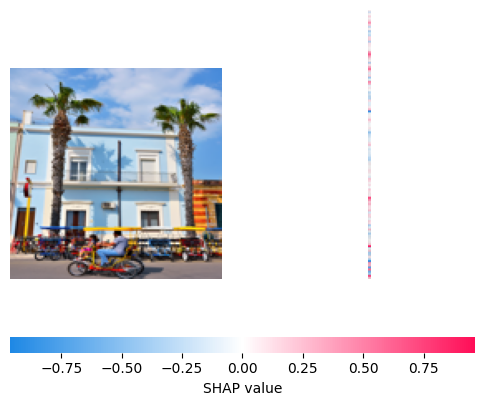

In [24]:
import shap
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from timm import create_model

# ---- Load model ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=128)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# ---- Image preprocessing ----
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- Sample image paths ----
image_paths = [
    "data/test_data_v2/0a4b8569dd9f4c1296c8e622b3bcbdf9.jpg",
    "data/test_data_v2/0a9c0ceb42124fdebbd1c1f8c2a6fb45.jpg",
    "data/test_data_v2/0aa09ccdc8ef40e9924cc7b75822722a.jpg"
]

# ---- Load images and convert to tensor ----
originals = []
input_tensors = []

for path in image_paths:
    img = Image.open(path).convert("RGB").resize((128, 128))
    originals.append(np.array(img).astype(np.float32) / 255.0)  # shape (H, W, C)
    tensor = transform(img).unsqueeze(0)  # shape (1, C, H, W)
    input_tensors.append(tensor)

inputs = torch.cat(input_tensors).to(device)
background = inputs[:2]  # 2 as background, 1 for testing

# ---- SHAP explainer ----
explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(inputs[2:])  # shape: list with (1, C, H, W)

# ---- Format SHAP values ----
# SHAP returns [array] even for binary output. Get [0]
shap_values = shap_values[0]  # shape: (1, C, H, W)

# Convert (C, H, W) -> (H, W, C) for image_plot
shap_values = np.transpose(shap_values, (0, 2, 3, 1))  # (1, 128, 128, 3)
pixel_values = np.array(originals[2:])  # shape (1, 128, 128, 3)

# ---- Plot ----
shap.image_plot(shap_values, pixel_values)


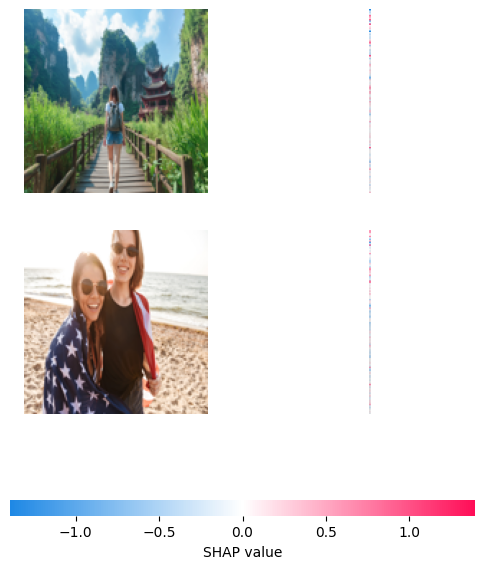

In [28]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
from torchvision import transforms
from timm import create_model

# ----- Config -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
folder = "data/test_data_v2"
img_size = 128

# ----- Model -----
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=img_size)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# ----- Image preprocessing -----
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----- Load Random Images -----
image_files = os.listdir(folder)
sample_files = random.sample(image_files, 3)

originals = []
inputs = []

for file in sample_files:
    img_path = os.path.join(folder, file)
    image = Image.open(img_path).convert("RGB")
    originals.append(np.array(image.resize((img_size, img_size))).astype(np.float32) / 255.0)
    tensor = transform(image).unsqueeze(0)
    inputs.append(tensor)

inputs = torch.cat(inputs).to(device)

# ----- SHAP Gradient Explainer -----
background = inputs[:1]
test_samples = inputs[1:]

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_samples)

# ----- SHAP formatting -----
shap_values = shap_values[0]  # Binary output

# SHAP gives (N, C, H, W) → convert to (N, H, W, C)
shap_values = np.transpose(shap_values, (0, 2, 3, 1))
pixel_values = np.stack(originals[1:])

# Clip values for clean plot
pixel_values = np.clip(pixel_values, 0, 1)

# ----- Plot -----
shap.image_plot(shap_values, pixel_values)


SHAP + LIME

100%|██████████| 1000/1000 [00:05<00:00, 171.74it/s]


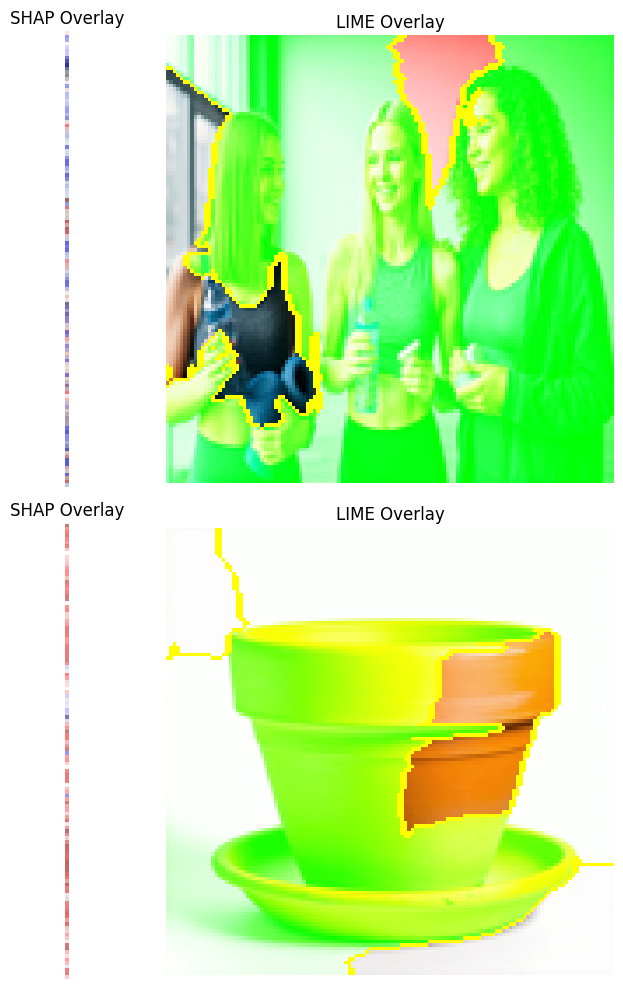

In [34]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from timm import create_model
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_size = 128
folder = "data/test_data_v2"

# --- Load Model ---
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=img_size)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# --- Image Preprocessing ---
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Load 3 Random Images ---
image_files = os.listdir(folder)
sample_files = random.sample(image_files, 3)

original_images = []
tensor_inputs = []

for file in sample_files:
    img_path = os.path.join(folder, file)
    img = Image.open(img_path).convert("RGB")
    resized = img.resize((img_size, img_size))
    original_images.append(np.array(resized).astype(np.float32) / 255.0)
    tensor_inputs.append(transform(resized).unsqueeze(0))

inputs = torch.cat(tensor_inputs).to(device)

# --- SHAP ---
background = inputs[:1]
test_inputs = inputs[1:]

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_inputs)  # list of arrays
shap_values = shap_values[0]                      # (N, C, H, W)
shap_values = np.transpose(shap_values, (0, 2, 3, 1))  # (N, H, W, C)
shap_pixels = np.stack(original_images[1:])
shap_pixels = np.clip(shap_pixels, 0, 1)

# --- LIME Classifier Wrapper ---
def batch_predict(images):
    model.eval()
    batch = torch.stack([
        transform(Image.fromarray(img)).to(device)
        for img in images
    ])
    with torch.no_grad():
        logits = model(batch).squeeze()
        probs = torch.sigmoid(logits).cpu().numpy()
    
    # Return (N, 2): [class 0 prob, class 1 prob]
    return np.stack([1 - probs, probs], axis=1)

lime_explainer = lime_image.LimeImageExplainer()

# --- Plot SHAP + LIME Side-by-Side ---
fig, axes = plt.subplots(len(shap_pixels), 2, figsize=(8, 10))

for idx, img_np in enumerate(shap_pixels):
    # --- SHAP ---
    axes[idx, 0].imshow(img_np)
    shap_img = shap_values[idx].sum(-1)
    axes[idx, 0].imshow(shap_img, cmap='seismic', alpha=0.5)
    axes[idx, 0].set_title(f"SHAP Overlay")
    axes[idx, 0].axis("off")

    # --- LIME ---
    explanation = lime_explainer.explain_instance(
        image=np.uint8(img_np * 255),
        classifier_fn=batch_predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    lime_img, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[0],
        positive_only=False,
        hide_rest=False,
        num_features=10,
        min_weight=0.0
    )
    axes[idx, 1].imshow(mark_boundaries(lime_img, mask))
    axes[idx, 1].set_title("LIME Overlay")
    axes[idx, 1].axis("off")

plt.tight_layout()
plt.show()


Top Image:

SHAP: Sparse contribution focused on torso/bottle.

LIME: Highlights the people as the most relevant regions.

Bottom Image:

SHAP: Again very sparse. Might mean ViT has highly localized attention.

LIME: Highlights the pot's right rim and middle—likely areas that influence classification (AI or Human).

100%|██████████| 1000/1000 [00:06<00:00, 146.10it/s]


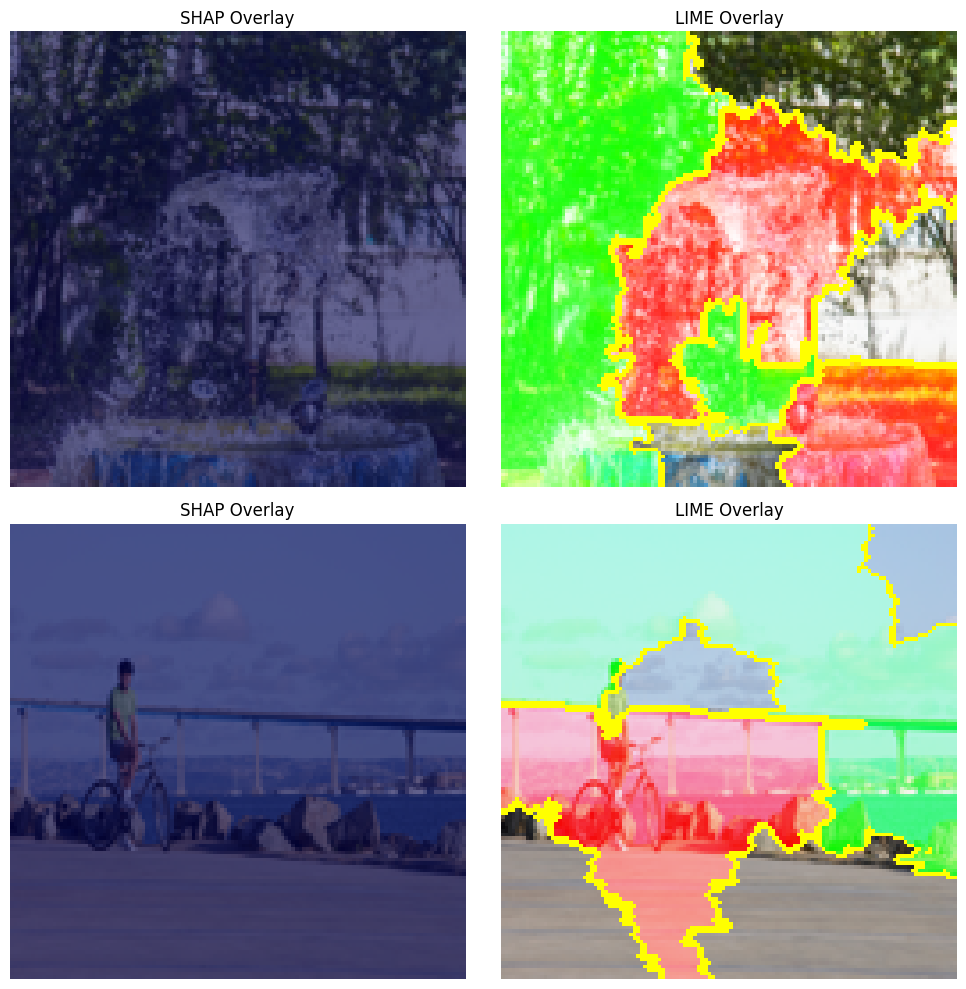

In [39]:
import os
import random
import numpy as np
import torch
from torchvision import transforms
from PIL import Image
import shap
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from timm import create_model

# ---- Config ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "data/test_data_v2"
model_path = "vit_tiny_best.pth"
num_samples = 2  # change to more if needed

# ---- Model Setup ----
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=128)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval().to(device)

# ---- Transform ----
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- Random Sample Selection ----
all_files = [f for f in os.listdir(data_dir) if f.endswith(".jpg")]
sampled_files = random.sample(all_files, num_samples)

original_images = []
input_tensors = []

for file in sampled_files:
    image_path = os.path.join(data_dir, file)
    image = Image.open(image_path).convert("RGB")
    original_images.append(np.array(image.resize((128, 128))).astype(np.float32) / 255.0)

    tensor_img = transform(image).unsqueeze(0).to(device)
    input_tensors.append(tensor_img)

input_batch = torch.cat(input_tensors)

# ---- SHAP Gradient Explainer ----
background = input_batch[:1]  # use 1 image as baseline
explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(input_batch)

# Format SHAP
shap_array = shap_values[0]
shap_array = np.transpose(shap_array, (0, 2, 3, 1))  # (B, H, W, C)

# ---- LIME Setup ----
def batch_predict(images_np):
    model.eval()
    images = torch.tensor(np.transpose(images_np, (0, 3, 1, 2))).float()
    images = transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225])(images)
    outputs = model(images.to(device))
    return torch.sigmoid(outputs).detach().cpu().numpy()

lime_explainer = lime_image.LimeImageExplainer()

# ---- Plot SHAP and LIME Side-by-Side ----
fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5 * num_samples))
for i in range(num_samples):
    img = original_images[i]

    # SHAP
    axes[i, 0].imshow(img)
    axes[i, 0].imshow(shap_array[i].squeeze(), cmap="seismic", alpha=0.6)
    axes[i, 0].axis('off')
    axes[i, 0].set_title("SHAP Overlay")

    # LIME
    explanation = lime_explainer.explain_instance(
        image=np.uint8(img * 255),
        classifier_fn=batch_predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    lime_img, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=False,
        hide_rest=False,
        num_features=8,
        min_weight=0.0
    )
    axes[i, 1].imshow(mark_boundaries(lime_img / 255.0, mask))
    axes[i, 1].axis('off')
    axes[i, 1].set_title("LIME Overlay")

plt.tight_layout()
plt.show()


100%|██████████| 100/100 [00:00<00:00, 199.77it/s]


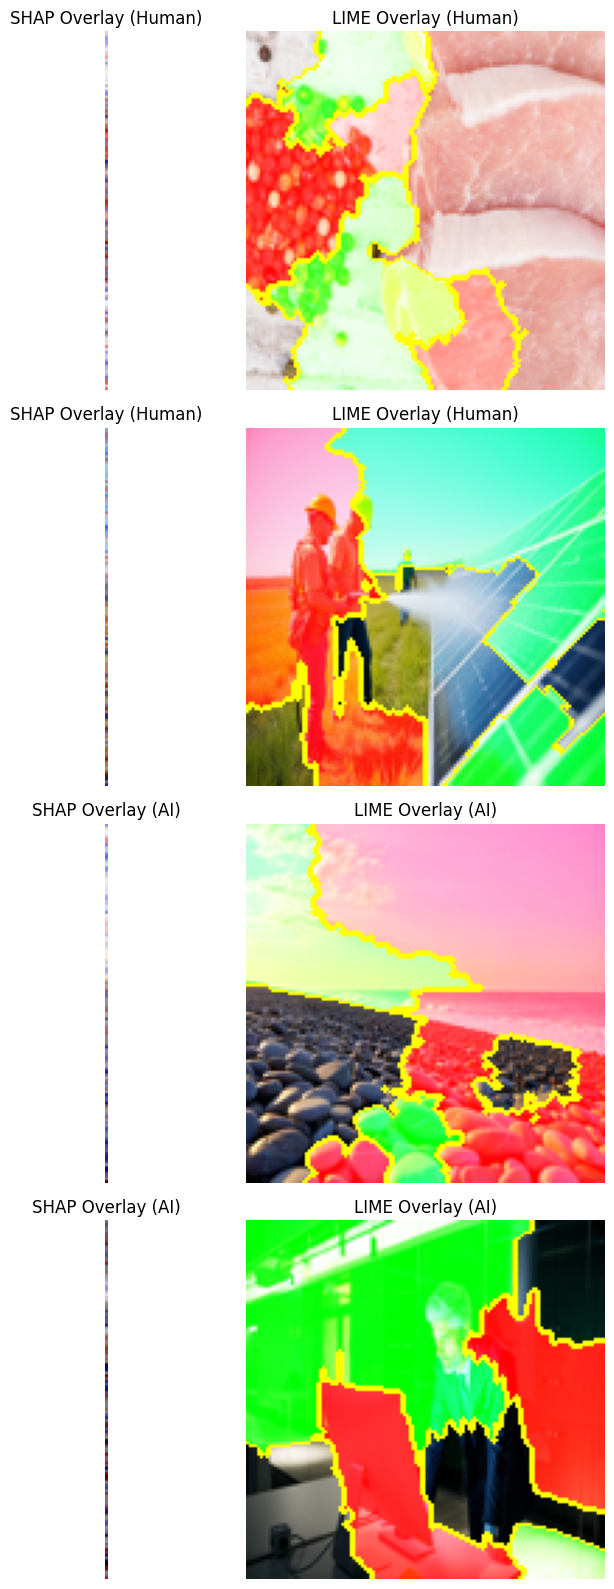

In [41]:
import os
import random
import torch
import shap
import numpy as np
from PIL import Image
from timm import create_model
from lime import lime_image
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from torchvision import transforms

# --- Config ---
img_dir = "data/test_data_v2"
img_size = 128
num_per_class = 2

# Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=img_size)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# Transform
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load files
all_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])
random.shuffle(all_files)
human_imgs = all_files[:num_per_class]
ai_imgs = all_files[-num_per_class:]
images_to_explain = human_imgs + ai_imgs

# SHAP
background = torch.cat([
    transform(Image.open(os.path.join(img_dir, f)).convert("RGB")).unsqueeze(0)
    for f in human_imgs
], dim=0).to(device)
shap_explainer = shap.GradientExplainer(model, background)

# LIME
lime_explainer = lime_image.LimeImageExplainer()
def batch_predict(images):
    model.eval()
    batch = torch.stack([transform(Image.fromarray(img)) for img in images]).to(device)
    with torch.no_grad():
        logits = model(batch)
    return torch.sigmoid(logits).cpu().numpy()

# --- Visualize ---
fig, axes = plt.subplots(len(images_to_explain), 2, figsize=(8, 4 * len(images_to_explain)))

for i, fname in enumerate(images_to_explain):
    label = "Human" if i < num_per_class else "AI"
    img_path = os.path.join(img_dir, fname)
    pil_img = Image.open(img_path).convert("RGB")
    np_img = np.array(pil_img.resize((img_size, img_size)))

    # SHAP
    input_tensor = transform(pil_img).unsqueeze(0).to(device)
    shap_vals = shap_explainer.shap_values(input_tensor)[0]
    shap_map = shap_vals[0].mean(axis=0)  # average across channels

    # LIME
    lime_exp = lime_explainer.explain_instance(np_img, batch_predict, top_labels=1, hide_color=0, num_samples=100)
    lime_img, lime_mask = lime_exp.get_image_and_mask(
        lime_exp.top_labels[0], positive_only=False, hide_rest=False, num_features=8, min_weight=0.0
    )
    lime_overlay = mark_boundaries(lime_img / 255.0, lime_mask)

    # Plot
    axes[i, 0].imshow(np_img)
    axes[i, 0].imshow(shap_map, cmap="seismic", alpha=0.5)
    axes[i, 0].set_title(f"SHAP Overlay ({label})")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(lime_overlay)
    axes[i, 1].set_title(f"LIME Overlay ({label})")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


100%|██████████| 1000/1000 [00:06<00:00, 144.59it/s]


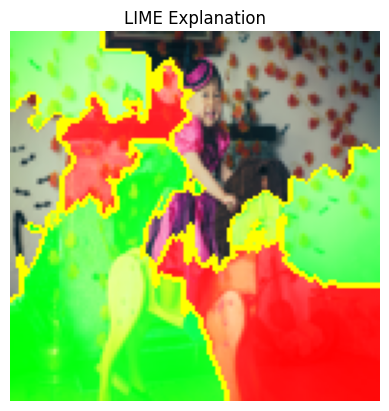

In [47]:
import torch
import numpy as np
from PIL import Image
from lime import lime_image
from torchvision import transforms
from timm import create_model
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=128)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# --- Load Image ---
img_path = "data/test_data_v2/ff2a443fcae1409096f2e6c1b084b1d5.jpg"  # 🔁 Replace with an actual image path
image = Image.open(img_path).convert("RGB")
img_np = np.array(image.resize((128, 128)))  # unnormalized RGB
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
img_tensor = transform(image).unsqueeze(0).to(device)

# --- LIME Explainer ---
def batch_predict(images):
    model.eval()
    batch = torch.stack([
        transform(Image.fromarray(img)).to(device)
        for img in images
    ])
    with torch.no_grad():
        outputs = model(batch).squeeze(1)
        probs = torch.sigmoid(outputs).cpu().numpy()
    return np.stack([1 - probs, probs], axis=1)  # class 0 vs 1

explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    image=img_np,
    classifier_fn=batch_predict,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

# --- Visualization ---
from skimage.color import label2rgb
temp, mask = explanation.get_image_and_mask(
    label=1,
    positive_only=False,
    hide_rest=False,
    num_features=10,
    min_weight=0.0
)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()


100%|██████████| 1000/1000 [00:06<00:00, 166.66it/s]


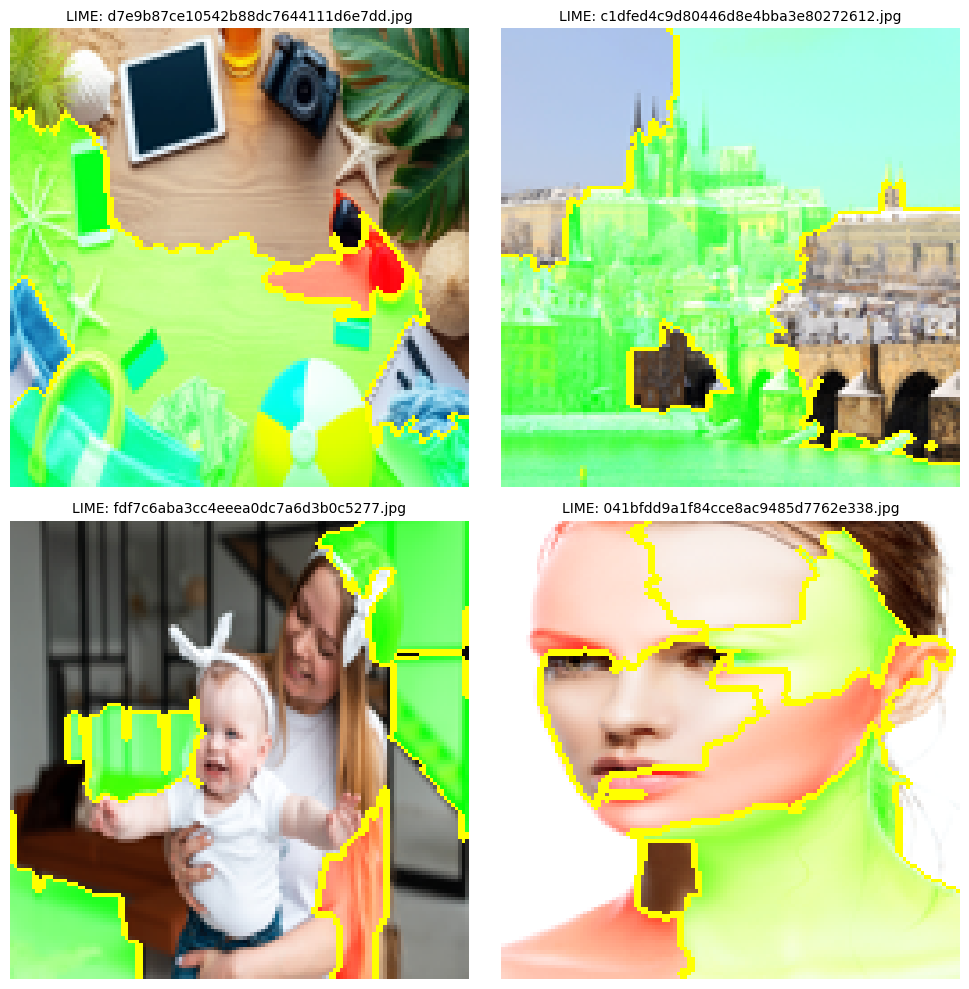

In [48]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import transforms
from timm import create_model

from lime import lime_image
from skimage.segmentation import mark_boundaries

# ---------------------
# 1. Load model
# ---------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=128)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# ---------------------
# 2. Preprocessing
# ---------------------
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict_fn(images):
    images = torch.stack([transform(Image.fromarray(img).convert("RGB")) for img in images]).to(device)
    with torch.no_grad():
        outputs = model(images).squeeze(1).cpu().numpy()
    return np.vstack([1 - outputs, outputs]).T  # for binary classification (class 0, class 1)

# ---------------------
# 3. Get random batch
# ---------------------
folder = "data/test_data_v2"
all_files = [f for f in os.listdir(folder) if f.endswith(".jpg")]
random_files = random.sample(all_files, 4)

# ---------------------
# 4. Run LIME
# ---------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
explainer = lime_image.LimeImageExplainer()

for i, filename in enumerate(random_files):
    path = os.path.join(folder, filename)
    image = np.array(Image.open(path).resize((128, 128)))

    explanation = explainer.explain_instance(
        image,
        predict_fn,
        labels=(0, 1),
        top_labels=1,
        num_samples=1000
    )

    lime_img, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[0],
        positive_only=False,
        hide_rest=False
    )

    ax = axes[i // 2, i % 2]
    ax.imshow(mark_boundaries(lime_img, mask))
    ax.set_title(f"LIME: {filename}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


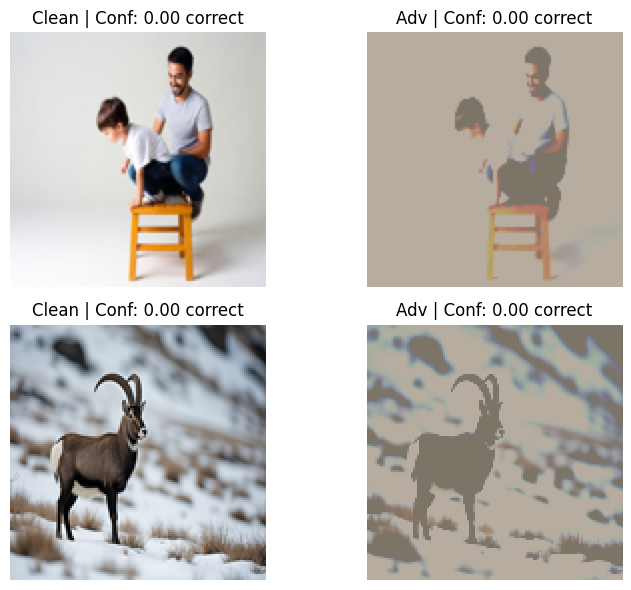

In [68]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from timm import create_model
import torchattacks

# --------------------
# 1. Load your model
# --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=1, img_size=128)
model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
model.eval().to(device)

# --------------------
# 2. Preprocess
# --------------------
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --------------------
# 3. Load Random Images
# --------------------
folder = "data/test_data_v2"
files = [f for f in os.listdir(folder) if f.endswith(".jpg")]
selected = random.sample(files, 2)

original_images = []
input_tensors = []

for file in selected:
    img_path = os.path.join(folder, file)
    img = Image.open(img_path).convert("RGB")
    original_images.append(np.array(img.resize((128, 128))) / 255.0)
    input_tensors.append(transform(img))

inputs = torch.stack(input_tensors).to(device)

# --------------------
# 4. Create attack
# --------------------
atk = torchattacks.FGSM(model, eps=8/255)

# Use predicted labels as pseudo ground-truth
with torch.no_grad():
    logits = model(inputs)
    labels = (logits > 0).long().view(-1)

# Apply attack
adv_images = atk(inputs, labels)

# --------------------
# 5. Evaluate
# --------------------
with torch.no_grad():
    outputs_clean = torch.sigmoid(model(inputs)).cpu().numpy()
    outputs_adv = torch.sigmoid(model(adv_images)).cpu().numpy()

# --------------------
# 6. Plot results
# --------------------
fig, axes = plt.subplots(len(selected), 2, figsize=(8, 6))

for i in range(len(selected)):
    clean_img = original_images[i]
    adv_img = adv_images[i].detach().cpu().numpy().transpose(1, 2, 0)
    adv_img = (adv_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))  # unnormalize
    adv_img = np.clip(adv_img, 0, 1)

    conf_clean = outputs_clean[i][0]
    conf_adv = outputs_adv[i][0]
    pred_clean = int(conf_clean > 0.5)
    pred_adv = int(conf_adv > 0.5)
    true_label = labels[i].item()

    mark_clean = "correct" if pred_clean == true_label else "False"
    mark_adv = "correct" if pred_adv == true_label else "False"

    axes[i, 0].imshow(clean_img)
    axes[i, 0].set_title(f"Clean | Conf: {conf_clean:.2f} {mark_clean}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(adv_img)
    axes[i, 1].set_title(f"Adv | Conf: {conf_adv:.2f} {mark_adv}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


### VIT vs CNN

In [39]:
# 📚 Imports
import torch
import numpy as np
import os, random
import matplotlib.pyplot as plt
from PIL import Image

from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import timm


In [40]:
# ⚙️ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [44]:
def reshape_transform_vit(tensor, height=8, width=8):
    # Remove CLS token, reshape from [B, N, C] → [B, C, H, W]
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.permute(0, 3, 1, 2)
    return result


In [41]:
# 🧪 Define transforms
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_vit = transforms.Compose([
    transforms.Resize((128, 128)),  # Match ViT training
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

input_tensor_resnet = transform_resnet(image).unsqueeze(0).to(device)
input_tensor_vit = transform_vit(image).unsqueeze(0).to(device)

original_image_resnet = np.array(image.resize((224, 224))).astype(np.float32) / 255.0
original_image_vit = np.array(image.resize((128, 128))).astype(np.float32) / 255.0


In [42]:
# 🧠 ResNet50 + Grad-CAM
cnn_model = models.resnet50(pretrained=True).eval().to(device)
cnn_target_layers = [cnn_model.layer4[-1]]

cnn_cam = GradCAM(model=cnn_model, target_layers=cnn_target_layers)
cnn_mask = cnn_cam(input_tensor=input_tensor_resnet, targets=[ClassifierOutputTarget(0)])[0]
cnn_result = show_cam_on_image(original_image_resnet, cnn_mask, use_rgb=True)


In [45]:
# 🧠 ViT + Grad-CAM (Trained on 128x128)
vit_model = timm.create_model("vit_tiny_patch16_224", pretrained=False, img_size=128, num_classes=1)
vit_model.load_state_dict(torch.load("vit_tiny_best.pth", map_location=device))
vit_model.eval().to(device)

vit_target_layers = [vit_model.blocks[-1].norm1]
vit_cam = GradCAM(
    model=vit_model,
    target_layers=vit_target_layers,
    reshape_transform=lambda x: reshape_transform_vit(x, 8, 8)
)



In [46]:
vit_mask = vit_cam(input_tensor=input_tensor_vit, targets=[ClassifierOutputTarget(0)])[0]
vit_result = show_cam_on_image(original_image_vit, vit_mask, use_rgb=True)


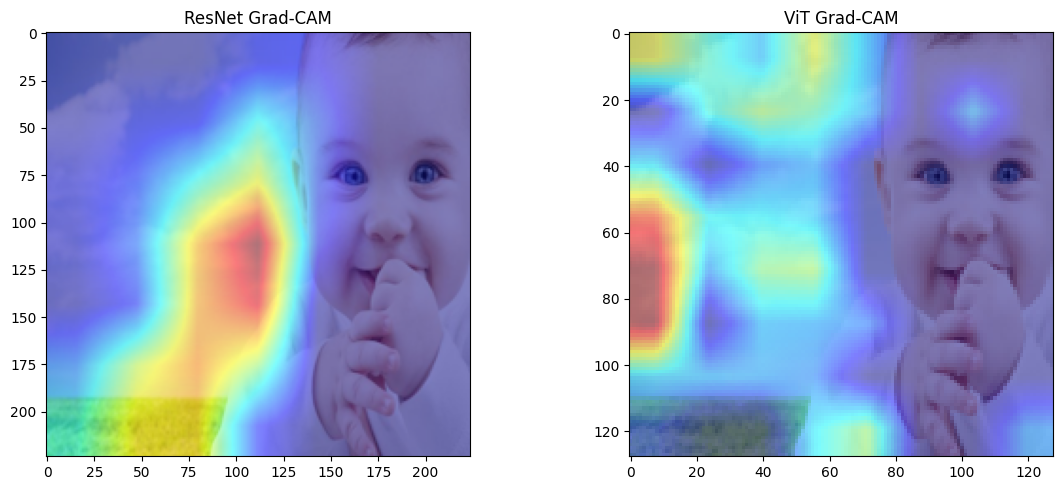

In [47]:
# 📊 Compare CAMs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cnn_result)
plt.title("ResNet Grad-CAM")

plt.subplot(1, 2, 2)
plt.imshow(vit_result)
plt.title("ViT Grad-CAM")

plt.tight_layout()
plt.show()


Left: ResNet Grad-CAM
Focused on background textures — shows classic CNN behavior.

Likely activating on low-level features (edges, textures, colors).

Limited semantic focus on the actual subject (baby).

Right: ViT Grad-CAM
Attends more to semantically meaningful areas — especially the baby’s face and hands.

Focus on the forehead and eye region suggests ViT is reasoning more globally.

However, it’s still a bit diffuse — common with ViTs due to token mixing.

### Patch-Level Fake Localization with ViT

In [57]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os, random
import cv2
from PIL import Image
from torchvision import transforms



In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [59]:
img_folder = "data/train_data"
image_files = [f for f in os.listdir(img_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random_img = random.choice(image_files)
img_path = os.path.join(img_folder, random_img)
image = Image.open(img_path).convert("RGB")
print(f"Selected image: {random_img}")


Selected image: ad35addf14dd46739028b981203f1b84.jpg


In [63]:
from transformers import ViTModel, ViTFeatureExtractor


In [64]:
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")
inputs = feature_extractor(images=image, return_tensors="pt")
input_tensor = inputs['pixel_values'].to(device)
original_image = np.array(image.resize((224, 224))).astype(np.float32) / 255.0


c:\Users\nandh\anaconda3\envs\cvenv\lib\site-packages\transformers\models\vit\feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [65]:
model = ViTModel.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
model.eval().to(device)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

In [66]:
with torch.no_grad():
    outputs = model(input_tensor)
    attn_maps = outputs.attentions  # List of [1, heads, tokens, tokens]

# Get attention from CLS to all patches in last layer
last_attn = attn_maps[-1]               # [1, heads, 197, 197]
cls_attn = last_attn[0, :, 0, 1:]       # Remove CLS token, shape: [heads, 196]
cls_attn = cls_attn.mean(0)             # Mean over heads → shape: [196]
cls_attn = cls_attn.reshape(14, 14).cpu().numpy()
cls_attn = cls_attn / cls_attn.max()


`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


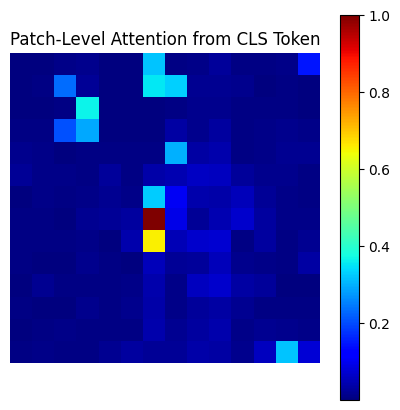

In [67]:
plt.figure(figsize=(5, 5))
plt.imshow(cls_attn, cmap='jet')
plt.title('Patch-Level Attention from CLS Token')
plt.colorbar()
plt.axis('off')
plt.show()


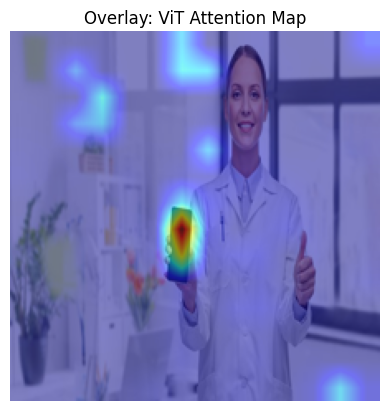

In [68]:
attn_resized = cv2.resize(cls_attn, (224, 224))
attn_overlay = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min())

# Overlay on original image
overlay_img = (original_image * 0.5 + plt.cm.jet(attn_overlay)[..., :3] * 0.5)

plt.imshow(overlay_img)
plt.title("Overlay: ViT Attention Map")
plt.axis('off')
plt.show()
